In [1]:
import pandas as pd
import numpy as np

C:\Users\Asus\AppData\Roaming\Python\Python312\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\Asus\AppData\Roaming\Python\Python312\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [2]:
nav_his = pd.read_csv("../Data/Processed/02_nav_history_cleaned.csv")

print(nav_his.head())
print(nav_his.shape)

   amfi_code        date       nav
0     100016  2022-01-03  520.4608
1     100016  2022-01-04  515.0971
2     100016  2022-01-05  521.7239
3     100016  2022-01-06  515.7880
4     100016  2022-01-07  515.1639
(46000, 3)


In [3]:
nav_his['amfi_code'].nunique()

40

In [4]:
nav_his.info()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  str    
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 1.5 MB


In [5]:
nav_his['date']=pd.to_datetime(nav_his['date'])

In [6]:
nav_his=nav_his.sort_values(['amfi_code','date'])

In [7]:
nav_his['daily_return'] = (nav_his.groupby('amfi_code')['nav']).pct_change()

In [8]:
nav_his

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
...,...,...,...,...
45995,149324,2026-05-25,292.4810,0.012106
45996,149324,2026-05-26,291.2707,-0.004138
45997,149324,2026-05-27,288.8007,-0.008480
45998,149324,2026-05-28,280.6873,-0.028093


In [9]:
nav_his['daily_return'].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

In [10]:
nav_his['daily_return'].isna().sum()

# First record of each scheme is Nan , so 40 missing values are there

40

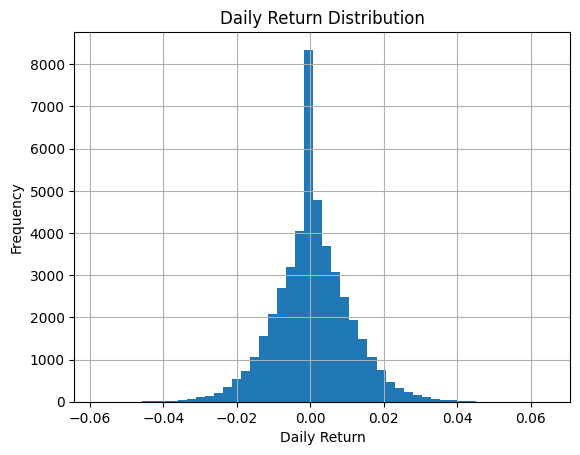

In [11]:
import matplotlib.pyplot as plt

nav_his['daily_return'].hist(bins=50)
plt.title('Daily Return Distribution')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.show()

In [12]:
## The distribution appears reasonable 

# 2 

In [13]:
nav_his['date'].min(), nav_his['date'].max()

(Timestamp('2022-01-03 00:00:00'), Timestamp('2026-05-29 00:00:00'))

In [14]:
nav_his.groupby('amfi_code')['date'].max()

amfi_code
100016   2026-05-29
100025   2026-05-29
100033   2026-05-29
101206   2026-05-29
101207   2026-05-29
101208   2026-05-29
102885   2026-05-29
102886   2026-05-29
102887   2026-05-29
118632   2026-05-29
118633   2026-05-29
118634   2026-05-29
118635   2026-05-29
118636   2026-05-29
119092   2026-05-29
119093   2026-05-29
119094   2026-05-29
119095   2026-05-29
119120   2026-05-29
119551   2026-05-29
119552   2026-05-29
119598   2026-05-29
119599   2026-05-29
120503   2026-05-29
120504   2026-05-29
120505   2026-05-29
120506   2026-05-29
120507   2026-05-29
120841   2026-05-29
120842   2026-05-29
120843   2026-05-29
120844   2026-05-29
125497   2026-05-29
125498   2026-05-29
148567   2026-05-29
148568   2026-05-29
148569   2026-05-29
149322   2026-05-29
149323   2026-05-29
149324   2026-05-29
Name: date, dtype: datetime64[us]

In [15]:
fund = nav_his[nav_his['amfi_code'] == 100016]

fund[fund['date'].between('2025-05-25', '2025-06-05')]

,amfi_code,date,nav,daily_return
885,100016,2025-05-26,602.9794,-0.002951
886,100016,2025-05-27,605.3287,0.003896
887,100016,2025-05-28,598.6729,-0.010995
888,100016,2025-05-29,596.8877,-0.002982
889,100016,2025-05-30,596.9773,0.000150
890,100016,2025-06-02,591.5240,-0.009135
891,100016,2025-06-03,601.2816,0.016496
892,100016,2025-06-04,597.0806,-0.006987
893,100016,2025-06-05,593.8721,-0.005374


In [16]:
nav_his['date'] = pd.to_datetime(nav_his['date'])

In [17]:
import pandas as pd
import numpy as np

nav_his['date'] = pd.to_datetime(nav_his['date'])

latest_date = nav_his['date'].max()

def calculate_cagr(nav_data, years):
    
    target_date = latest_date - pd.DateOffset(years=years)

    results = []

    for amfi_code, fund in nav_data.groupby('amfi_code'):

        fund = fund.sort_values('date')

        if fund['date'].min() > target_date:
            results.append({
                'amfi_code': amfi_code,
                f'cagr_{years}y': np.nan
            })
            continue

        end_nav = fund.loc[
            fund['date'] == latest_date,
            'nav'
        ].iloc[0]

        start_row = (
            fund[fund['date'] <= target_date]
            .sort_values('date')
            .iloc[-1]
        )

        start_date = start_row['date']
        start_nav = start_row['nav']

        trading_days = len(
            fund[
                (fund['date'] >= start_date) &
                (fund['date'] <= latest_date)
            ]
        )

        cagr = (end_nav / start_nav) ** (252 / trading_days) - 1

        results.append({
            'amfi_code': amfi_code,
            f'cagr_{years}y': cagr
        })

    return pd.DataFrame(results)

In [18]:
cagr_1y_df = calculate_cagr(nav_his, 1)

cagr_3y_df = calculate_cagr(nav_his, 3)

cagr_5y_df = calculate_cagr(nav_his, 5)

In [19]:
cagr_df = (
    cagr_1y_df
    .merge(cagr_3y_df, on='amfi_code')
    .merge(cagr_5y_df, on='amfi_code')
)

cagr_df.head()

,amfi_code,cagr_1y,cagr_3y,cagr_5y
0,100016,-0.021403,0.012446,NaN
1,100025,0.035611,0.037690,NaN
2,100033,0.507565,0.310748,NaN
3,101206,0.457300,0.277613,NaN
4,101207,-0.231862,-0.040021,NaN


In [20]:
cagr_df.isna().sum()

amfi_code     0
cagr_1y       0
cagr_3y       0
cagr_5y      40
dtype: int64

In [21]:
### 5-Year CAGR

# The available NAV history spans from January 2022 to May 2026, which provides less than 5 years of historical data.

# As a result, a true 5-Year CAGR cannot be calculated for any scheme. Therefore, the 5-Year CAGR values are reported as NaN (Not Available) to avoid using insufficient data and producing misleading results.

# 3

In [22]:
import numpy as np
import pandas as pd

daily_rf = 0.065 / 252

sharpe_data = []

for amfi_code, fund in nav_his.groupby('amfi_code'):

    returns = fund['daily_return'].dropna()

    mean_return = returns.mean()
    std_return = returns.std()
    sharpe = ((mean_return - daily_rf) / std_return) * np.sqrt(252)
    sharpe_data.append({
        'amfi_code': amfi_code,
        'sharpe_ratio': sharpe
    })

sharpe_df = pd.DataFrame(sharpe_data)

sharpe_df.head()

,amfi_code,sharpe_ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [23]:
sharpe_df['sharpe_ratio'].describe()

count    40.000000
mean      0.537220
std       0.573689
min      -0.815567
25%       0.064696
50%       0.647043
75%       1.005304
max       1.448291
Name: sharpe_ratio, dtype: float64

In [24]:
sharpe_df = sharpe_df.sort_values(
    'sharpe_ratio',
    ascending=False
)

sharpe_df['sharpe_rank'] = range(
    1,
    len(sharpe_df) + 1
)

In [25]:
sharpe_df.head()

,amfi_code,sharpe_ratio,sharpe_rank
34,148567,1.448291,1
30,120843,1.306744,2
36,148569,1.234930,3
19,119551,1.208267,4
25,120505,1.180101,5


# 4 

In [26]:
daily_rf = 0.065 / 252

sortino_data = []

for amfi_code, fund in nav_his.groupby('amfi_code'):
    returns = fund['daily_return'].dropna()
    mean_return = returns.mean()
    downside_returns = returns[returns < 0]
    downside_std = downside_returns.std()
    sortino = ((mean_return - daily_rf) / downside_std) * np.sqrt(252)
    sortino_data.append({
        'amfi_code': amfi_code,
        'sortino_ratio': sortino
    })
sortino_df = pd.DataFrame(sortino_data)
sortino_df.head()

,amfi_code,sortino_ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [27]:
sortino_df['sortino_ratio'].describe()

count    40.000000
mean      0.923338
std       1.005410
min      -1.681038
25%       0.106664
50%       1.116936
75%       1.727739
max       2.385644
Name: sortino_ratio, dtype: float64

# 5

In [28]:
df_5 = pd.read_csv("../Data/Processed/10_benchmark_indices_cleaned.csv")

print(df_5.head())
print(df_5.shape)

         date index_name  close_value
0  2022-01-03    NIFTY50     17492.79
1  2022-01-04    NIFTY50     17689.64
2  2022-01-05    NIFTY50     17835.05
3  2022-01-06    NIFTY50     17878.51
4  2022-01-07    NIFTY50     17759.15
(8050, 3)


In [29]:
df_5['index_name'].unique()

<ArrowStringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str

In [30]:
nifty100 = df_5[df_5['index_name'] == 'NIFTY100'].copy()

In [31]:
nifty100['date'] = pd.to_datetime(nifty100['date'])
nifty100 = nifty100.sort_values('date')
nifty100['benchmark_return'] = (
    nifty100['close_value']
    .pct_change()
)

In [32]:
nifty100[['date','benchmark_return']].head()

,date,benchmark_return
1150,2022-01-03,NaN
1151,2022-01-04,-0.013540
1152,2022-01-05,0.004003
1153,2022-01-06,-0.002935
1154,2022-01-07,0.006150


In [33]:
from scipy.stats import linregress

In [34]:
alpha_beta_data = []

for amfi_code in nav_his['amfi_code'].unique():

    # Getting Fund Data 
    fund_data = nav_his[nav_his['amfi_code'] == amfi_code]

    # Merging with benchmark returns
    merged_data = pd.merge(
        fund_data[['date', 'daily_return']],
        nifty100[['date', 'benchmark_return']],
        on='date'
    )

    # Removing missing values
    merged_data = merged_data.dropna()
    slope, intercept, r_value, p_value, std_err = linregress(
        merged_data['benchmark_return'],
        merged_data['daily_return']
    )

    alpha = intercept * 252
    beta = slope

    alpha_beta_data.append({
        'amfi_code': amfi_code,
        'alpha': alpha,
        'beta': beta
    })

alpha_beta_df = pd.DataFrame(alpha_beta_data)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [35]:
alpha_beta_df.describe()

,amfi_code,alpha,beta
count,40.000000,40.000000,40.000000
mean,120247.000000,0.159085,-0.001958
std,14534.998667,0.087528,0.035194
min,100016.000000,0.028969,-0.066951
25%,118632.750000,0.068612,-0.023937
50%,119551.500000,0.162326,-0.000067
75%,120842.250000,0.221723,0.017026
max,149324.000000,0.303370,0.103497


In [36]:
alpha_beta_df.to_csv("../Data/Processed/alpha_beta.csv",index=False)

# 6

In [37]:
fund = nav_his[nav_his['amfi_code'] == 100016].copy()
fund = fund.sort_values('date')
fund['running_max'] = fund['nav'].cummax()
fund['drawdown'] = (fund['nav'] / fund['running_max']) - 1
fund[['date', 'nav', 'running_max', 'drawdown']].head(15)


,date,nav,running_max,drawdown
0,2022-01-03,520.4608,520.4608,0.000000
1,2022-01-04,515.0971,520.4608,-0.010306
2,2022-01-05,521.7239,521.7239,0.000000
3,2022-01-06,515.7880,521.7239,-0.011377
4,2022-01-07,515.1639,521.7239,-0.012574
5,2022-01-10,510.7136,521.7239,-0.021104
6,2022-01-11,513.5542,521.7239,-0.015659
7,2022-01-12,512.3195,521.7239,-0.018026
8,2022-01-13,510.2445,521.7239,-0.022003
9,2022-01-14,514.3636,521.7239,-0.014108


In [38]:
fund['drawdown'].min()

-0.24734440880673303

In [39]:
fund.loc[fund['drawdown'].idxmin()]

amfi_code                    100016
date            2022-09-15 00:00:00
nav                        411.1759
daily_return              -0.019696
running_max                546.3002
drawdown                  -0.247344
Name: 183, dtype: object

In [40]:
max_drawdown_data = []

for amfi_code in nav_his['amfi_code'].unique():

    fund_data = nav_his[nav_his['amfi_code'] == amfi_code].copy()

    fund_data = fund_data.sort_values('date')

    fund_data['running_max'] = fund_data['nav'].cummax()

    fund_data['drawdown'] = (
        fund_data['nav'] / fund_data['running_max']
    ) - 1

    max_drawdown = fund_data['drawdown'].min()

    drawdown_row = fund_data.loc[
        fund_data['drawdown'].idxmin()
    ]

    trough_date = drawdown_row['date']

    peak_nav = drawdown_row['running_max']

    peak_date = fund_data[
        fund_data['nav'] == peak_nav
    ]['date'].iloc[0]

    max_drawdown_data.append({
        'amfi_code': amfi_code,
        'max_drawdown': max_drawdown,
        'peak_date': peak_date,
        'trough_date': trough_date
    })

max_dd_df = pd.DataFrame(max_drawdown_data)

max_dd_df.head()

,amfi_code,max_drawdown,peak_date,trough_date
0,100016,-0.247344,2022-03-30,2022-09-15
1,100025,-0.043083,2023-05-23,2023-07-28
2,100033,-0.162172,2022-03-11,2022-05-12
3,101206,-0.112916,2023-04-24,2023-07-05
4,101207,-0.354469,2024-11-21,2026-05-11


In [41]:
max_dd_df.to_csv("../Data/Processed/max_drawdown.csv",index=False)

In [42]:
fund_master = pd.read_csv("../Data/Processed/01_fund_master_cleaned.csv")

scorecard_data = (cagr_df[['amfi_code', 'cagr_3y']]
    .merge(sharpe_df[['amfi_code', 'sharpe_ratio']], on='amfi_code')
    .merge(alpha_beta_df[['amfi_code', 'alpha']], on='amfi_code')
    .merge(max_dd_df[['amfi_code', 'max_drawdown']], on='amfi_code')
    .merge(
        fund_master[['amfi_code', 'expense_ratio_pct']],
        on='amfi_code'
    )
)

scorecard_data.head()

,amfi_code,cagr_3y,sharpe_ratio,alpha,max_drawdown,expense_ratio_pct
0,100016,0.012446,-0.201517,0.037476,-0.247344,1.55
1,100025,0.037690,-0.567095,0.042818,-0.043083,0.56
2,100033,0.310748,1.093699,0.271954,-0.162172,1.38
3,101206,0.277613,1.027213,0.213998,-0.112916,1.60
4,101207,-0.040021,0.162661,0.108971,-0.354469,1.53


In [43]:
scorecard_data['cagr_rank'] = scorecard_data['cagr_3y'].rank(ascending=False)
scorecard_data['sharpe_rank'] = scorecard_data['sharpe_ratio'].rank(ascending=False)
scorecard_data['alpha_rank'] = scorecard_data['alpha'].rank(ascending=False)
scorecard_data['expense_rank'] = scorecard_data['expense_ratio_pct'].rank(ascending=True)
scorecard_data['drawdown_rank'] = scorecard_data['max_drawdown'].rank(ascending=False)

In [44]:
scorecard_data.head()

,amfi_code,cagr_3y,sharpe_ratio,alpha,max_drawdown,expense_ratio_pct,cagr_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank
0,100016,0.012446,-0.201517,0.037476,-0.247344,1.55,35.0,35.0,39.0,32.0,34.0
1,100025,0.037690,-0.567095,0.042818,-0.043083,0.56,34.0,39.0,38.0,2.0,4.0
2,100033,0.310748,1.093699,0.271954,-0.162172,1.38,4.0,7.0,6.0,17.0,20.0
3,101206,0.277613,1.027213,0.213998,-0.112916,1.60,9.0,9.0,12.0,36.5,9.0
4,101207,-0.040021,0.162661,0.108971,-0.354469,1.53,39.0,28.0,27.0,28.5,38.0


In [45]:
scorecard_data['score'] = (
    0.30 * scorecard_data['cagr_rank'] +
    0.25 * scorecard_data['sharpe_rank'] +
    0.20 * scorecard_data['alpha_rank'] +
    0.15 * scorecard_data['expense_rank'] +
    0.10 * scorecard_data['drawdown_rank']
)

In [46]:
scorecard_data['overall_rank'] = (scorecard_data['score'].rank(method='dense')
)

In [47]:
scorecard_data.sort_values('score').head(10)

,amfi_code,cagr_3y,sharpe_ratio,alpha,max_drawdown,expense_ratio_pct,cagr_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,score,overall_rank
34,148567,0.325599,1.448291,0.269838,-0.112657,1.46,2.0,1.0,7.0,23.0,8.0,6.500,1.0
25,120505,0.304410,1.180101,0.292636,-0.181885,1.36,5.0,5.0,3.0,15.0,25.0,8.100,2.0
30,120843,0.283481,1.306744,0.273305,-0.129740,1.45,7.0,2.0,5.0,22.0,13.0,8.200,3.0
2,100033,0.310748,1.093699,0.271954,-0.162172,1.38,4.0,7.0,6.0,17.0,20.0,8.700,4.0
24,120504,0.311177,1.026524,0.211948,-0.125883,0.80,3.0,10.0,13.0,12.0,12.0,9.000,5.0
16,119094,0.336180,0.998231,0.260767,-0.209609,1.38,1.0,11.0,9.0,17.0,28.0,10.200,6.0
19,119551,0.291815,1.208267,0.232010,-0.150124,1.54,6.0,4.0,10.0,30.5,17.0,11.075,7.0
36,148569,0.279628,1.234930,0.282704,-0.163967,1.60,8.0,3.0,4.0,36.5,21.0,11.525,8.0
3,101206,0.277613,1.027213,0.213998,-0.112916,1.60,9.0,9.0,12.0,36.5,9.0,13.725,9.0
21,119598,0.255684,0.945308,0.303370,-0.287060,1.43,12.0,14.0,1.0,21.0,36.0,14.050,10.0


In [48]:
scorecard_data['fund_score'] = (
    (scorecard_data['score'].max() - scorecard_data['score']) / (scorecard_data['score'].max() - scorecard_data['score'].min())) * 100

In [49]:
scorecard_data['fund_score'] = (scorecard_data['fund_score'].round(2))

In [50]:
scorecard_data[['amfi_code','fund_score']].head()

,amfi_code,fund_score
0,100016,0.09
1,100025,24.41
2,100033,92.35
3,101206,74.89
4,101207,10.77


In [51]:
scorecard_data['fund_score'].describe()

count     40.000000
mean      51.346250
std       29.009657
min        0.000000
25%       27.935000
50%       52.780000
75%       73.107500
max      100.000000
Name: fund_score, dtype: float64

In [52]:
scorecard_data = scorecard_data.sort_values('fund_score',ascending=False)

scorecard_data.head(10)

,amfi_code,cagr_3y,sharpe_ratio,alpha,max_drawdown,expense_ratio_pct,cagr_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,score,overall_rank,fund_score
34,148567,0.325599,1.448291,0.269838,-0.112657,1.46,2.0,1.0,7.0,23.0,8.0,6.500,1.0,100.00
25,120505,0.304410,1.180101,0.292636,-0.181885,1.36,5.0,5.0,3.0,15.0,25.0,8.100,2.0,94.44
30,120843,0.283481,1.306744,0.273305,-0.129740,1.45,7.0,2.0,5.0,22.0,13.0,8.200,3.0,94.09
2,100033,0.310748,1.093699,0.271954,-0.162172,1.38,4.0,7.0,6.0,17.0,20.0,8.700,4.0,92.35
24,120504,0.311177,1.026524,0.211948,-0.125883,0.80,3.0,10.0,13.0,12.0,12.0,9.000,5.0,91.31
16,119094,0.336180,0.998231,0.260767,-0.209609,1.38,1.0,11.0,9.0,17.0,28.0,10.200,6.0,87.14
19,119551,0.291815,1.208267,0.232010,-0.150124,1.54,6.0,4.0,10.0,30.5,17.0,11.075,7.0,84.10
36,148569,0.279628,1.234930,0.282704,-0.163967,1.60,8.0,3.0,4.0,36.5,21.0,11.525,8.0,82.54
3,101206,0.277613,1.027213,0.213998,-0.112916,1.60,9.0,9.0,12.0,36.5,9.0,13.725,9.0,74.89
21,119598,0.255684,0.945308,0.303370,-0.287060,1.43,12.0,14.0,1.0,21.0,36.0,14.050,10.0,73.76


In [53]:
scorecard_data.to_csv("../Data/Processed/fund_scorecard.csv",index=False)

# 7

In [54]:
top5_funds = scorecard_data.sort_values('fund_score',ascending=False).head(5)
top5_funds[['amfi_code', 'fund_score']]

,amfi_code,fund_score
34,148567,100.00
25,120505,94.44
30,120843,94.09
2,100033,92.35
24,120504,91.31


In [55]:
top5_codes = [148567, 120505, 120843, 100033, 120504]

top5_nav = nav_his[nav_his['amfi_code'].isin(top5_codes)].copy()

top5_nav.head()

,amfi_code,date,nav,daily_return
2300,100033,2022-01-03,107.3758,NaN
2301,100033,2022-01-04,105.9447,-0.013328
2302,100033,2022-01-05,105.4800,-0.004386
2303,100033,2022-01-06,104.9350,-0.005167
2304,100033,2022-01-07,104.3318,-0.005748


In [56]:
top5_nav['amfi_code'].nunique()

5

In [57]:
latest_date = nav_his['date'].max()

three_years_ago = latest_date - pd.DateOffset(years=3)

In [58]:
top5_nav_3y = top5_nav[top5_nav['date'] >= three_years_ago].copy()

top5_nav_3y.head()

,amfi_code,date,nav,daily_return
2665,100033,2023-05-29,147.2155,0.004216
2666,100033,2023-05-30,147.2007,-0.000101
2667,100033,2023-05-31,147.4640,0.001789
2668,100033,2023-06-01,146.5954,-0.005890
2669,100033,2023-06-02,145.8015,-0.005416


In [59]:
nifty50 = df_5[df_5['index_name'] == 'NIFTY50'].copy()
nifty100 = df_5[df_5['index_name'] == 'NIFTY100'].copy()

In [60]:
nifty50_3y = nifty50[pd.to_datetime(nifty50['date']) >= three_years_ago].copy()

nifty100_3y = nifty100[pd.to_datetime(nifty100['date']) >= three_years_ago].copy()

In [61]:
print(top5_nav_3y.shape)
print(nifty50_3y.shape)
print(nifty100_3y.shape)

(3925, 4)
(785, 3)
(785, 3)


In [62]:
top5_nav_3y = top5_nav_3y.sort_values(['amfi_code', 'date'])

top5_nav_3y['normalized_nav'] = (
    top5_nav_3y['nav'] /
    top5_nav_3y.groupby('amfi_code')['nav'].transform('first')) * 100

In [63]:
nifty50_3y = nifty50_3y.sort_values('date')

nifty50_3y['normalized_value'] = (
    nifty50_3y['close_value'] /
    nifty50_3y['close_value'].iloc[0]
) * 100

In [64]:
nifty100_3y = nifty100_3y.sort_values('date')

nifty100_3y['normalized_value'] = (
    nifty100_3y['close_value'] /
    nifty100_3y['close_value'].iloc[0]
) * 100

In [65]:
top5_nav_3y[['amfi_code','date','normalized_nav']].head()

,amfi_code,date,normalized_nav
2665,100033,2023-05-29,100.000000
2666,100033,2023-05-30,99.989947
2667,100033,2023-05-31,100.168800
2668,100033,2023-06-01,99.578781
2669,100033,2023-06-02,99.039503


In [66]:
nifty50_3y[['date','normalized_value']].head()

,date,normalized_value
365,2023-05-29,100.000000
366,2023-05-30,99.471337
367,2023-05-31,99.138796
368,2023-06-01,98.733023
369,2023-06-02,98.826345


In [67]:
top5_nav_3y['date'] = pd.to_datetime(top5_nav_3y['date'])
nifty50_3y['date'] = pd.to_datetime(nifty50_3y['date'])
nifty100_3y['date'] = pd.to_datetime(nifty100_3y['date'])

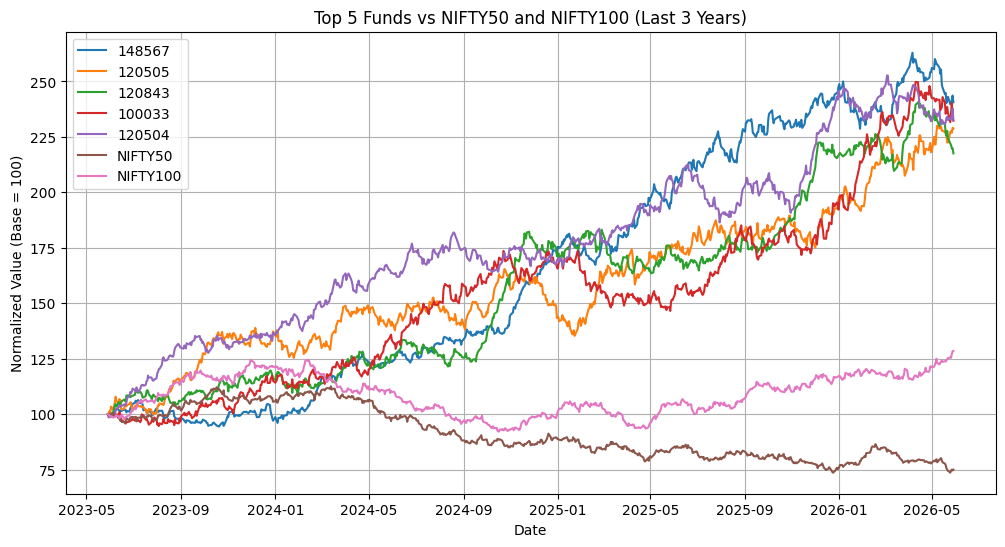

In [68]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for amfi_code in top5_codes:

    fund = top5_nav_3y[
        top5_nav_3y['amfi_code'] == amfi_code
    ]

    plt.plot(
        fund['date'],
        fund['normalized_nav'],
        label=str(amfi_code)
    )

plt.plot(
    nifty50_3y['date'],
    nifty50_3y['normalized_value'],
    label='NIFTY50'
)

plt.plot(
    nifty100_3y['date'],
    nifty100_3y['normalized_value'],
    label='NIFTY100'
)

plt.title('Top 5 Funds vs NIFTY50 and NIFTY100 (Last 3 Years)')
plt.xlabel('Date')
plt.ylabel('Normalized Value (Base = 100)')
plt.legend()
plt.grid(True)

plt.show()

In [69]:
df_5['index_name'].unique()

<ArrowStringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str

In [70]:
df_5.groupby('index_name')['close_value'].agg(['min','max'])

,min,max
index_name,,
BSE_SMALLCAP,23592.64,79075.39
CRISIL_GILT,1444.13,2302.79
CRISIL_LIQUID,2281.51,3046.00
NIFTY100,14128.86,21088.58
NIFTY50,17492.79,27798.72
NIFTY500,14426.04,38418.87
NIFTY_MIDCAP150,8980.60,32990.66


In [71]:
nifty100['date'] = pd.to_datetime(nifty100['date'])

nifty100 = nifty100.sort_values('date')
nifty100['benchmark_return'] = (nifty100['close_value'].pct_change())

In [72]:
import numpy as np

tracking_error_data = []

for amfi_code, fund in nav_his.groupby('amfi_code'):

    merged = pd.merge(
        fund[['date', 'daily_return']],
        nifty100[['date', 'benchmark_return']],
        on='date'
    )

    merged = merged.dropna()

    diff = (
        merged['daily_return']- merged['benchmark_return']
    )

    tracking_error = diff.std() * np.sqrt(252)

    tracking_error_data.append({
        'amfi_code': amfi_code,
        'tracking_error': tracking_error
    })
tracking_error_df = pd.DataFrame(tracking_error_data)
tracking_error_df.head()

,amfi_code,tracking_error
0,100016,0.199284
1,100025,0.134535
2,100033,0.228699
3,101206,0.192706
4,101207,0.292117


In [73]:
tracking_error_df['tracking_error'].describe()

count    40.000000
mean      0.203626
std       0.044056
min       0.128957
25%       0.188786
50%       0.193357
75%       0.224096
max       0.292117
Name: tracking_error, dtype: float64

In [74]:
tracking_error_df.to_csv("../Data/Processed/tracking_error.csv",index=False)